In [12]:
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os
#loading database info to variables from the .env file
load_dotenv()
db_host = os.getenv('POSTGRES_HOST')
db_port = os.getenv('POSTGRES_PORT')
db_user = os.getenv('POSTGRES_USER')
db_password = os.getenv('POSTGRES_PASSWORD')
db_name = os.getenv('POSTGRES_DB')

#passing all db info to one string variable
connection_string = f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
engine = create_engine(connection_string)
#retrieving data from the db
sql_query = '''
    SELECT * FROM fact_listings fl
    LEFT JOIN dim_listings dl ON fl.listings_id = dl.id
    LEFT JOIN dim_hosts h ON dl.host_id = h.host_id;
'''
df_all = pd.read_sql_query(sql_query, engine)
df_all = df_all.rename(columns={
    'id': 'dim_listings_id'
})
print('DataFrame załadowany poprawnie')
df_all.head()

DataFrame załadowany poprawnie


,listings_id,quarter,year,price,dim_listings_id,name,description,property_type,room_type,accommodates,...,host_verifications,host_has_profile_pic,host_identity_verified,host_listings_count,host_total_listings_count,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,license
0,21853,Q2,2025,29.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
1,21853,Q1,2025,29.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
2,21853,Q4,2024,31.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
3,21853,Q3,2024,31.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
4,24805,Q3,2024,104.0,24805,Gran Via Studio Madrid,"Studio located 50 meters from Gran Via, next t...",Entire rental unit,Entire home/apt,3,...,"['email', 'phone']",True,True,1.0,1.0,1,1,0,0,None


In [15]:
df_all.dtypes

listings_id                                       int64
quarter                                          object
year                                              int64
price                                           float64
dim_listings_id                                   int64
name                                             object
description                                      object
property_type                                    object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bathrooms_description                            object
bedrooms                                        float64
beds                                            float64
amenities                                        object
minimum_nights                                    int64
maximum_nights                                    int64
has_availability                                

In [20]:
null_count = df_all.isnull().sum()
print(null_count)

listings_id                                         0
quarter                                             0
year                                                0
price                                               0
dim_listings_id                                     0
name                                                0
description                                      3052
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                        7118
bathrooms_description                             119
bedrooms                                         2195
beds                                             7105
amenities                                           0
minimum_nights                                      0
maximum_nights                                      0
has_availability                                  745
instant_bookable            

In [27]:
print(f'Number of rows before cleaning: {len(df_all)}')
df_all_clean = df_all.dropna(subset=['beds', 'host_is_superhost', 'host_verifications', 
                      'host_has_profile_pic', 'host_identity_verified', 
                      'host_listings_count', 'host_total_listings_count', 
                      'review_scores_rating', 'review_scores_accuracy',
                      'review_scores_cleanliness', 'review_scores_checkin',
                      'review_scores_communication', 'review_scores_location', 
                      'review_scores_value', 'host_acceptance_rate',
                      'host_response_time', 'host_response_rate'])
print('Verified and dropped null values in key columns')
print(f'Number of rows after cleaning: {len(df_all_clean)}')
print(df_all_clean.isnull().sum())

Number of rows before cleaning: 100189
Verified and dropped null values in key columns
Number of rows after cleaning: 74386
listings_id                                         0
quarter                                             0
year                                                0
price                                               0
dim_listings_id                                     0
name                                                0
description                                      2162
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                          29
bathrooms_description                              36
bedrooms                                           87
beds                                                0
amenities                                           0
minimum_nights                                      0
maximum_nigh

In [46]:
df_all_clean['price'].describe()

count    74386.000000
mean       130.090245
std        310.531604
min          8.000000
25%         67.000000
50%        101.000000
75%        147.000000
max      25654.000000
Name: price, dtype: float64

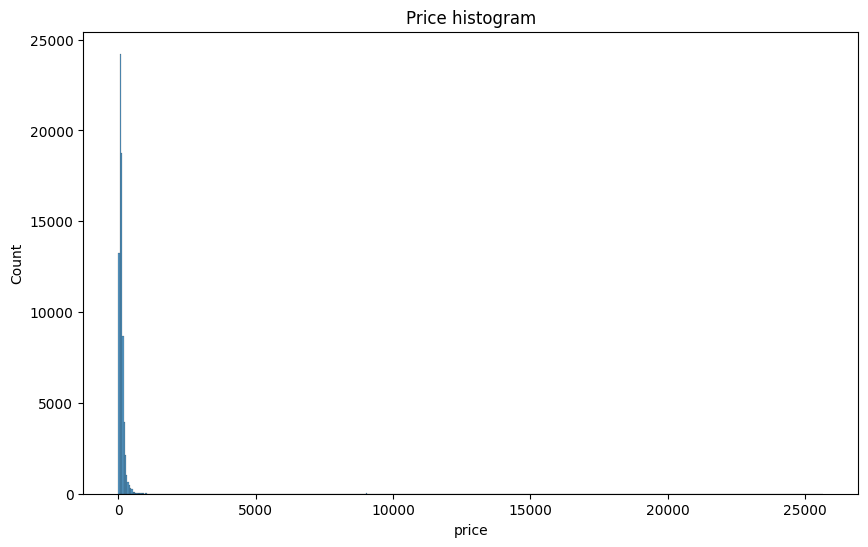

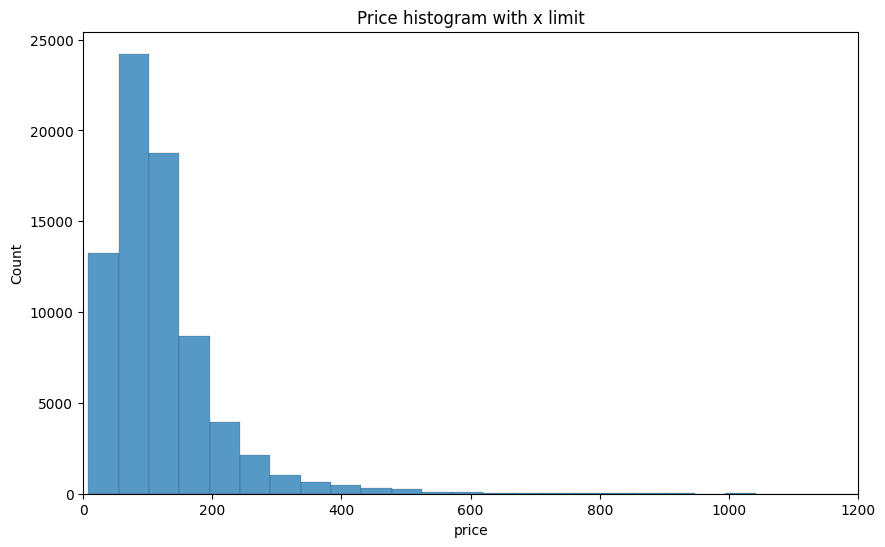

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#histogram to visualize price distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_all_clean, x='price')
plt.title('Price histogram')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_all_clean, x='price')
plt.title('Price histogram with x limit')
plt.xlim(0, 1200)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

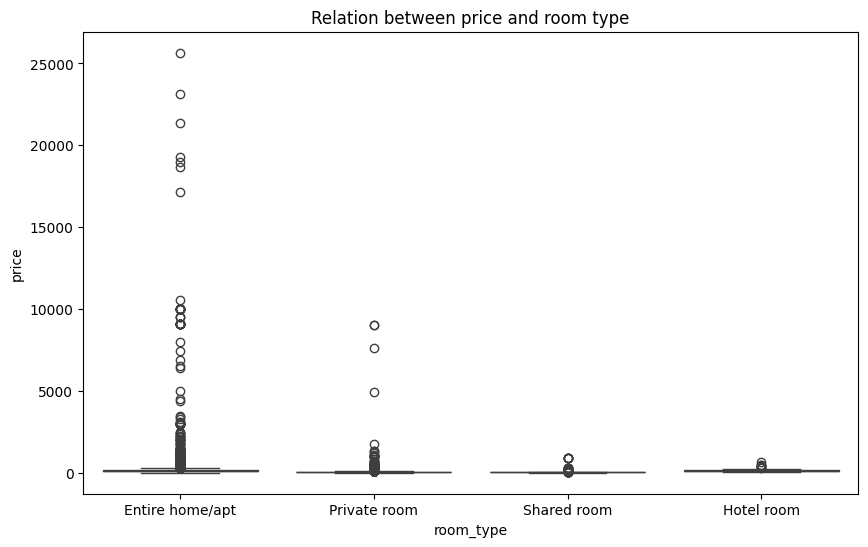

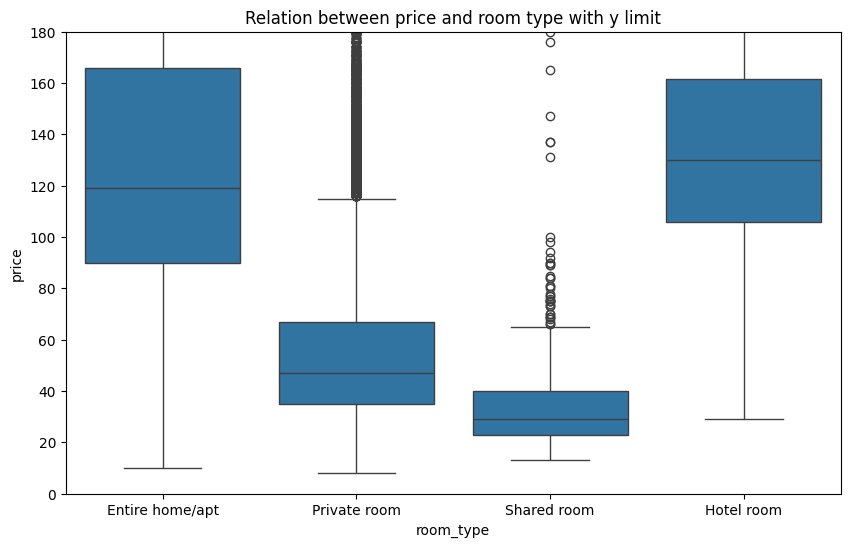

In [ ]:
#boxplot to visualize price ranges for different room types
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_clean, x='room_type', y='price')
plt.title('Relation between price and room type')
plt.show

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_clean, x='room_type', y='price')
plt.title('Relation between price and room type with y limit')
plt.ylim(0, 180)
plt.show

In [ ]:
#interquartile range to find price outliers for entire home/apt
df_entire_home = df_all_clean['room_type'] == 'Entire home/apt' #poprawić
q1 = df_entire_home['price'].quantile(0.25)
q3 = df_entire_home['price'].quantile(0.75)
iqr = q3-q1
upper_bound = q3 + (1.5 * iqr)

mask = df_entire_home['price'] > upper_bound
print(df_entire_home[mask])

KeyError: 'price'